## ZeroShot evaluation on BanglaCalamityMMD dataset

### Load dataset from drive

In [ ]:
#Define paths
zip_path = '/content/drive/MyDrive/BanglaCalamityMMD.zip'   # ← Update this path
extract_path = '/content/BanglaCalamityMMD'

#Extract using 7z
!apt-get install -y p7zip-full > /dev/null 2>&1

import os
if not os.path.exists(extract_path):
    print("Extracting the dataset... (this may take 5-15 minutes the first time)")
    !7z x "{zip_path}" -o"{extract_path}" -y
else:
    print("Dataset already extracted. Skipping extraction.")

Extracting the dataset... (this may take 5-15 minutes the first time)

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/                                 1 file, 1957873322 bytes (1868 MiB)

Extracting archive: /content/drive/MyDrive/BanglaCalamityMMD.zip
 51% 4096 Open              --
Path = /content/drive/MyDrive/BanglaCalamityMMD.zip
Type = zip
Physical Size = 1957873322

  0%      0% 15 - BanglaCalamityMMD/Test/drought_811.jpg                                                  0% 51 - BanglaCalamityMMD/Test/drought_847.jpg           

In [ ]:
# Check if loaded correctly
import os
print("Files/folders in dataset root:", os.listdir("/content/BanglaCalamityMMD"))

Files/folders in dataset root: ['BanglaCalamityMMD']


### Format Dataset: Text and Image paths

In [ ]:
import pandas as pd
import os
from PIL import Image

def load_test_data(dataset_root="/content/BanglaCalamityMMD"):
    # Add paths of testing files for text and images
    csv_path = os.path.join(dataset_root, "BanglaCalamityMMD/Disaster_test.csv")
    images_dir = os.path.join(dataset_root, "BanglaCalamityMMD/Test")

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found at: {csv_path}")
    if not os.path.exists(images_dir):
        raise FileNotFoundError(f"Test images folder not found at: {images_dir}")

    df = pd.read_csv(csv_path)
    print("Original CSV columns:", df.columns.tolist())

    # Standardize column names
    df = df.rename(columns={
        "image_id": "image_filename",
        "context": "caption",
        "category": "true_label"
    })

    def get_image_path(row):
        filename = str(row["image_filename"]).strip()
        base_path = os.path.join(images_dir, filename)

        # Image path neyar shomoy extension ta add kora chhilo na oita kortesi ekhane
        # Common extensions for images (this is to avoid any errors of FileType)
        for ext in [".jpg", ".jpeg", ".png", ""]:
            full_path = base_path + ext
            if os.path.exists(full_path):
                return full_path
        # If nothing works, return original (for debugging)
        return base_path

    df["image_path"] = df.apply(get_image_path, axis=1)

    # Verify a few paths
    print("\nExample corrected image path:", df.iloc[0]["image_path"])
    print("Does first image exist?", os.path.exists(df.iloc[0]["image_path"]))

    # Count missing files
    missing = df[~df["image_path"].apply(os.path.exists)]
    if len(missing) > 0:
        print(f"⚠️  Warning: {len(missing)} images not found!")
    else:
        print("✅ All image paths are valid!")

    return df

# Run the loader
test_df = load_test_data()

print("\nTest samples loaded:", len(test_df))
print(test_df[["true_label"]].value_counts())
print("\nExample row:\n", test_df.iloc[0])

Original CSV columns: ['image_id', 'context', 'category']

Example corrected image path: /content/BanglaCalamityMMD/BanglaCalamityMMD/Test/landslides_804.jpg
Does first image exist? True
✅ All image paths are valid!

Test samples loaded: 790
true_label    
Drought           100
Earthquake        100
Flood             100
Human Damage      100
Landslides        100
Non Disaster      100
Tropical Storm    100
Wildfire           90
Name: count, dtype: int64

Example row:
 image_filename                                       landslides_804
caption           গত মাসে ইতালির ইস্কিয়া দ্বীপে ভূমিধসে নিখোঁজ ...
true_label                                               Landslides
image_path        /content/BanglaCalamityMMD/BanglaCalamityMMD/T...
Name: 0, dtype: object


### Parse Prediction
Predictions might be in Bangla but the labels are in english, so we map the predictions to the right label for maximum accuracy

In [ ]:
import re

CLASSES = ["Earthquake", "Flood", "Landslides", "Wildfire", "Tropical Storm", "Drought", "Human Damage", "Non Disaster"]

def parse_prediction(response: str):
    if not isinstance(response, str):
        return "Non Disaster"

    response_lower = response.lower().strip()
    response_orig = response.strip()

    # 1. English class names (in case the predictions are in english)
    class_map = {
        "earthquake": "Earthquake",
        "flood": "Flood",
        "landslide": "Landslides",
        "landslides": "Landslides",
        "hillslide": "Landslides",
        "mudslide": "Landslides",
        "wildfire": "Wildfire",
        "fire": "Wildfire",
        "tropical storm": "Tropical Storm",
        "tornado": "Tropical Storm",
        "storm": "Tropical Storm",
        "cyclone": "Tropical Storm",
        "hurricane": "Tropical Storm",
        "typhoon": "Tropical Storm",
        "drought": "Drought",
        "water": "Drought",
        "human damage": "Human Damage",
        "war": "Human Damage",
        "bombing": "Human Damage",
        "explosion": "Human Damage",
        "bomb": "Human Damage",
        "attack": "Human Damage",
        "destruction": "Human Damage",
        "destroy": "Human Damage",
        "collapse": "Human Damage",
        "damage": "Human Damage",
        "non disaster": "Non Disaster",
        "normal": "Non Disaster",
        "no disaster": "Non Disaster"
    }

    for eng, label in class_map.items():
        if eng in response_lower:
            return label

    # 2. Bangla terms (usually the predictions will be in Bangla)
    bangla_map = {
        "ভূমিকম্প": "Earthquake",
        "ভূমিকম্পের": "Earthquake",
        "বন্যা": "Flood",
        "যমুনা": "Flood",
        "বৃষ্টি": "Flood",
        "বন্যার": "Flood",
        "ভূমিধস": "Landslides",
        "ভূমিধস": "Landslides",
        "ভূমিসৃতি": "Landslides",
        "ভূমিধ্বস": "Landslides",
        "ভূমি ক্ষয়": "Landslides",
        "মাডস্লাইড": "Landslides",
        "হিলস্লাইড": "Landslides",
        "দাবানল": "Wildfire",
        "অগ্নিকাণ্ড": "Wildfire",
        "বনের আগুন": "Wildfire",
        "ঘূর্ণিঝড়": "Tropical Storm",
        "টর্নেডো": "Tropical Storm",
        "হারিকেন": "Tropical Storm",
        "ঝড়": "Tropical Storm",
        "ঘূর্ণাবর্ত": "Tropical Storm",
        "ট্রপিক্যাল": "Tropical Storm",
        "খরা": "Drought",
        "জলের অভাবে": "Drought",
        "জল নাই": "Drought",
        "শুষ্কজল": "Drought",
        "বৃষ্টি নেই": "Drought",
        "ক্ষুধা": "Drought",
        "পানি কম": "Drought",
        "জল সংকট": "Drought",
        "পানির ঘাটতি": "Drought",
        "অভাবে": "Drought",
        "শুষ্ক": "Drought",
        "মানুষের ক্ষতি": "Human Damage",
        "ধ্বংস": "Human Damage",
        "মানবসৃষ্ট": "Human Damage",
        "মানব": "Human Damage",
        "বিস্ফোরণ": "Human Damage",
        "বিষক্রিয়া": "Human Damage",
        "দুর্ঘটনা": "Human Damage",
        "যুদ্ধ": "Human Damage",
        "লড়াই": "Human Damage",
        "হত্যা": "Human Damage",
        "ধর্মঘট": "Human Damage",
        "বোমা": "Human Damage",
        "হামলা": "Human Damage",
        "আক্রমণ": "Human Damage",
    }

    for bangla, label in bangla_map.items():
        if bangla in response_orig:   # keep original case for Bangla
            return label

    # 3. Fallback: if the response is very short or contains the class in any form
    for cls in CLASSES:
        if cls.lower() in response_lower:
            return cls

    return "Non Disaster"

# Eta emni banay rakhsilam, use kora hoy nai kothao
def evaluate(predictions, true_labels):
    correct = sum(1 for p, t in zip(predictions, true_labels) if p == t)
    accuracy = correct / len(predictions) * 100
    print(f"Zero-Shot Accuracy: {accuracy:.2f}%")
    return accuracy

### Evaluation Function

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import os

CLASSES = ["Earthquake", "Flood", "Landslides", "Wildfire", "Tropical Storm", "Drought", "Human Damage", "Non Disaster"]

def evaluate_model(predictions, true_labels, model_name="Model", save_dir="results"):
    os.makedirs(save_dir, exist_ok=True)

    y_true = np.array(true_labels)
    y_pred = np.array(predictions)

    # (kaeno jani class er class r label number mismatch error ashe tai eita kora)
    # === Force everything to be one of the 8 classes ===
    valid_classes = set(CLASSES)
    y_pred = np.array([pred if pred in valid_classes else "Non Disaster" for pred in y_pred])

    print(f"\n=== {model_name} Zero-Shot Evaluation ===")
    print(f"Total samples : {len(y_true)}")

    # Count distribution of predictions
    print("\nPredicted class distribution:")
    print(pd.Series(y_pred).value_counts())

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\nAccuracy           : {acc*100:.2f}%")
    print(f"Macro Precision    : {prec*100:.2f}%")
    print(f"Macro Recall       : {rec*100:.2f}%")
    print(f"Macro F1-score     : {f1*100:.2f}%")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                labels=CLASSES,           # Force exactly 8 classes
                                target_names=CLASSES,
                                digits=4,
                                zero_division=0))

    # Confusion Matrix (8x8 clean)
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Save results
    results_df = pd.DataFrame({
        "true_label": y_true,
        "predicted": y_pred,
        "raw_response": test_df.get("blip2_raw_response", [""]*len(test_df))
    })
    results_df.to_csv(f"{save_dir}/{model_name}_predictions.csv", index=False)

    print(f"\n✅ Results saved in ./{save_dir}/")
    return acc, prec, rec, f1

### Memory clear

Before loading and running any heavy model, run this to clear out cache from processor RAM. This makes sure noy OutofMemory error occurs.

While running Qwen, I was bombarded with this error. The GPU RAM was constantly running out of memory. The simple clear method in the main function was not working. So I shifted to a lighter version of Qwen (used 2B instead of 7B) and opted for this aggressive memory clear function.

In [ ]:
import torch
import gc

# Very aggressive memory clear
torch.cuda.empty_cache()
gc.collect()
torch.cuda.empty_cache()

# Optional: Reset CUDA cache
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.reset_accumulated_memory_stats()

print("Memory cleared. Current GPU memory:", torch.cuda.memory_allocated()/1024**3, "GB")

Memory cleared. Current GPU memory: 0.0 GB


### BLIP2

**Most Challenging Part:** Improving accuracy by better parsing.

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(
100%|██████████| 790/790 [1:33:16<00:00,  7.08s/it]



=== BLIP-2_ZeroShot Zero-Shot Evaluation ===
Total samples : 790

Predicted class distribution:
Non Disaster      155
Flood             147
Tropical Storm     92
Wildfire           92
Earthquake         90
Human Damage       78
Drought            73
Landslides         63
Name: count, dtype: int64

Accuracy           : 84.68%
Macro Precision    : 88.90%
Macro Recall       : 84.83%
Macro F1-score     : 85.03%

Classification Report:
                precision    recall  f1-score   support

    Earthquake     0.9889    0.8900    0.9368       100
         Flood     0.6667    0.9800    0.7935       100
    Landslides     1.0000    0.6300    0.7730       100
      Wildfire     0.9457    0.9667    0.9560        90
Tropical Storm     1.0000    0.9200    0.9583       100
       Drought     1.0000    0.7300    0.8439       100
  Human Damage     0.8718    0.6800    0.7640       100
  Non Disaster     0.6387    0.9900    0.7765       100

      accuracy                         0.8468       790
  

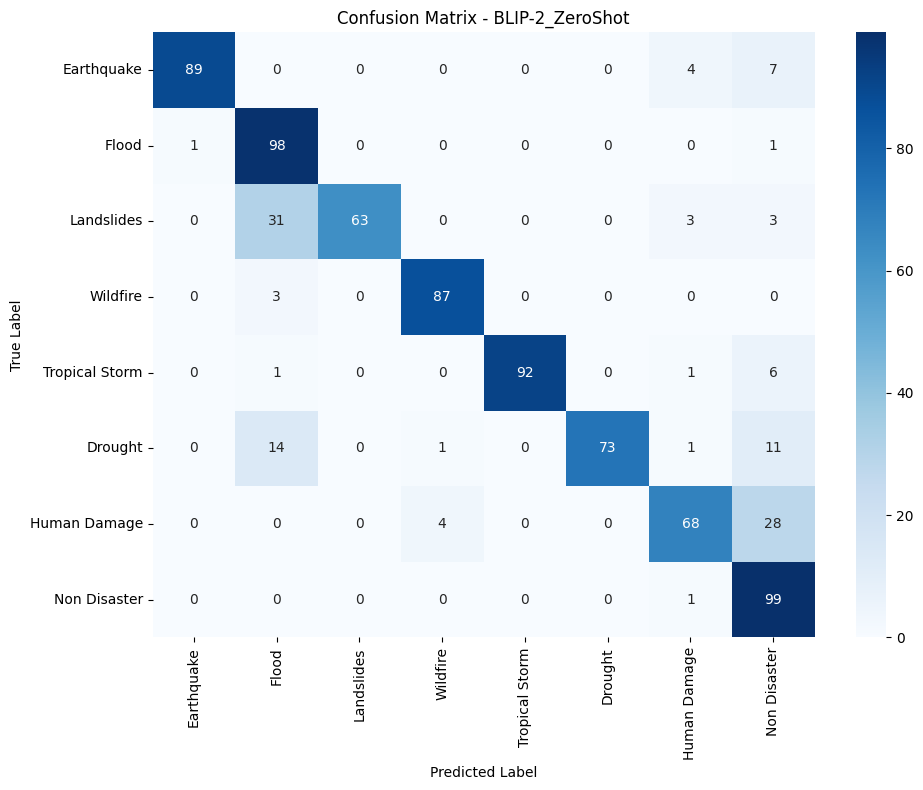


✅ Results saved in ./results/


In [ ]:
# ====================== INSTALL & IMPORT ======================
!pip install -q transformers torch accelerate

import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from tqdm import tqdm
import gc

# Clear memory
torch.cuda.empty_cache()
gc.collect()

# ======================= LOAD BLIP-2 ==========================
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16, device_map="auto")

# ======================= PROMPT =======================
PROMPT = "এই ছবিটি এবং টেক্সটটি দেখে বলুন এটি কোন ধরণের দুর্যোগ।"

# ====================== ZERO-SHOT FUNCTION ======================
def blip2_zero_shot(df):
    preds = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        image = Image.open(row["image_path"]).convert("RGB")
        text_input = f"{PROMPT}\nছবির টেক্সট: {row['caption']}"

        inputs = processor(images=image, text=text_input, return_tensors="pt").to(model.device)
        generated_ids = model.generate(**inputs, max_new_tokens=50)
        response = processor.decode(generated_ids[0], skip_special_tokens=True)
        preds.append(parse_prediction(response))
        raw_responses.append(response)
    return preds

# ====================== RUN EVALUATION ======================
predictions = blip2_zero_shot(test_df)
blip2_predictions = predictions

# Evaluate
blip2_acc, blip2_prec, blip2_rec, blip2_f1 = evaluate_model(
    predictions=predictions,
    true_labels=test_df["true_label"].tolist(),
    model_name="BLIP-2_ZeroShot"
)


=== BLIP-2_ZeroShot Zero-Shot Evaluation ===
Total samples : 790

Predicted class distribution:
Non Disaster      155
Flood             147
Tropical Storm     92
Wildfire           92
Earthquake         90
Human Damage       78
Drought            73
Landslides         63
Name: count, dtype: int64

Accuracy           : 84.68%
Macro Precision    : 88.90%
Macro Recall       : 84.83%
Macro F1-score     : 85.03%

Classification Report:
                precision    recall  f1-score   support

    Earthquake     0.9889    0.8900    0.9368       100
         Flood     0.6667    0.9800    0.7935       100
    Landslides     1.0000    0.6300    0.7730       100
      Wildfire     0.9457    0.9667    0.9560        90
Tropical Storm     1.0000    0.9200    0.9583       100
       Drought     1.0000    0.7300    0.8439       100
  Human Damage     0.8718    0.6800    0.7640       100
  Non Disaster     0.6387    0.9900    0.7765       100

      accuracy                         0.8468       790
  

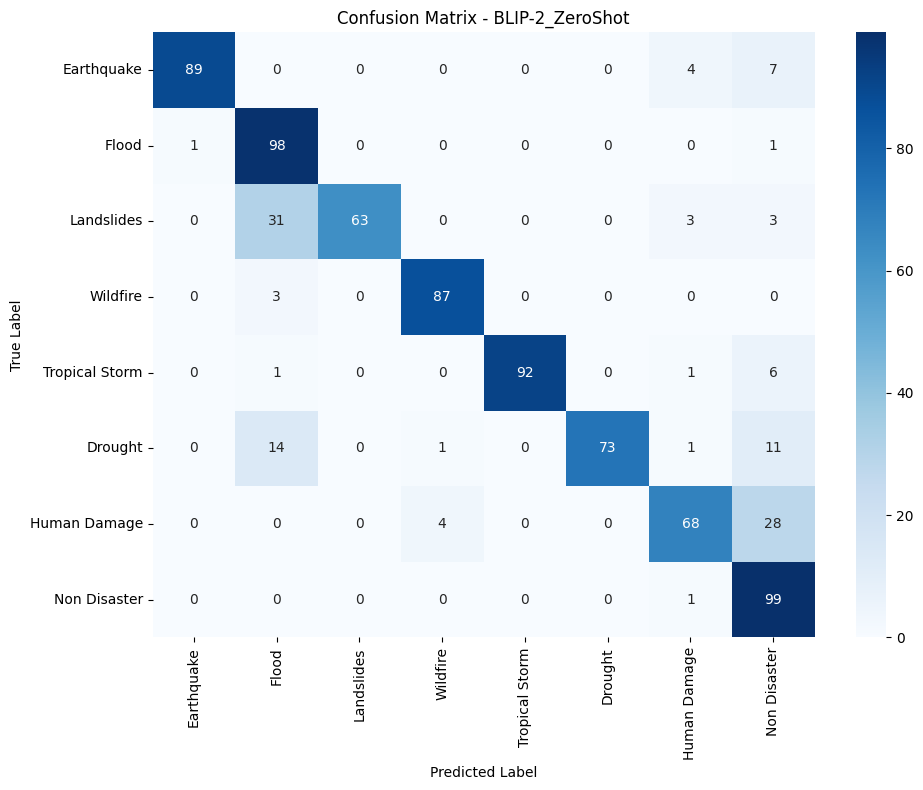


✅ Results saved in ./results/


In [ ]:
blip2_acc, blip2_prec, blip2_rec, blip2_f1 = evaluate_model(
    predictions=predictions,
    true_labels=test_df["true_label"].tolist(),
    model_name="BLIP-2_ZeroShot"
)

### Qwen2-VL-2B

**Most Challenging part:** The constant OutOfMemory errors

In [ ]:
!pip install qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 22.5 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00
Loading Qwen2-VL-2B in 4-bit...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

Error on one image: CUDA out of memory. Tried to allocate 27.20 GiB. GPU 0 has a total capacity of 14.56 GiB of which 10.69 GiB is free. Including non-PyTorch memory, this process has 3.87 GiB memory in use. Of the allocated memory 2.48 GiB is allocated by PyTorch, and 1.26 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


 95%|█████████▍| 749/790 [46:01<01:33,  2.28s/it]

Error on one image: CUDA out of memory. Tried to allocate 6.91 GiB. GPU 0 has a total capacity of 14.56 GiB of which 4.90 GiB is free. Including non-PyTorch memory, this process has 9.66 GiB memory in use. Of the allocated memory 8.82 GiB is allocated by PyTorch, and 725.67 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


100%|██████████| 790/790 [48:44<00:00,  3.70s/it]



=== Qwen2-VL-2B_ZeroShot Zero-Shot Evaluation ===
Total samples : 790

Predicted class distribution:
Non Disaster      124
Flood             123
Wildfire          112
Tropical Storm    101
Human Damage       94
Drought            91
Earthquake         89
Landslides         56
Name: count, dtype: int64

Accuracy           : 82.91%
Macro Precision    : 84.14%
Macro Recall       : 83.08%
Macro F1-score     : 82.43%

Classification Report:
                precision    recall  f1-score   support

    Earthquake     0.9326    0.8300    0.8783       100
         Flood     0.7886    0.9700    0.8700       100
    Landslides     0.9643    0.5400    0.6923       100
      Wildfire     0.7768    0.9667    0.8614        90
Tropical Storm     0.9802    0.9900    0.9851       100
       Drought     0.8901    0.8100    0.8482       100
  Human Damage     0.6489    0.6100    0.6289       100
  Non Disaster     0.7500    0.9300    0.8304       100

      accuracy                         0.8291       7

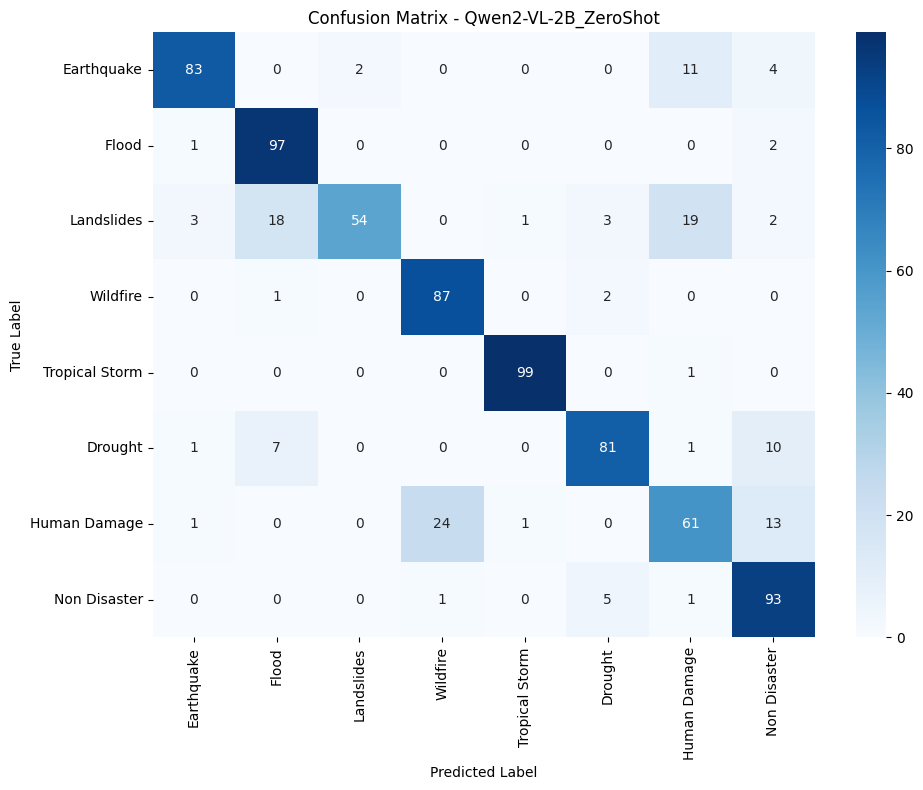


✅ Results saved in ./results/


In [ ]:
# ====================== INSTALL & IMPORT ======================
!pip install -q transformers accelerate bitsandbytes

import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info
from tqdm import tqdm
import gc

# Clear GPU memory
torch.cuda.empty_cache()
gc.collect()

# ====================== LOAD Qwen2-VL-2B ======================
print("Loading Qwen2-VL-2B in 4-bit...")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",           # ← 2B version
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)

processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    trust_remote_code=True
)

print("✅ Qwen2-VL-2B loaded successfully!")
print(f"GPU Memory Used: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# ====================== PROMPT ======================
PROMPT = "এই ছবিটি এবং টেক্সটটি দেখে বলুন এটি কোন ধরণের দুর্যোগ।"

# ====================== ZERO-SHOT FUNCTION ======================
def qwen2vl_zero_shot(df):
    preds = []
    print("Running Qwen2-VL-2B Zero-Shot...")

    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            messages = [
                {"role": "user", "content": [
                    {"type": "image", "image": row["image_path"]},
                    {"type": "text", "text": f"{PROMPT}\nছবির টেক্সট: {row['caption']}"}
                ]}
            ]

            text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            image_inputs, _ = process_vision_info(messages)

            inputs = processor(
                text=[text],
                images=image_inputs,
                padding=True,
                return_tensors="pt"
            ).to(model.device)

            generated_ids = model.generate(
                **inputs,
                max_new_tokens=50,
                do_sample=False,
                temperature=0.0
            )

            response = processor.decode(generated_ids[0], skip_special_tokens=True)
            parsed = parse_prediction(response)
            preds.append(parsed)

        except Exception as e:
            print(f"Error on one image: {e}")
            preds.append("Non-Disaster")

    return preds


# ====================== RUN EVALUATION ======================
qwen2vl_predictions = qwen2vl_zero_shot(test_df)

# Evaluate
qwen2vl_acc, qwen2vl_prec, qwen2vl_rec, qwen2vl_f1 = evaluate_model(
    predictions=qwen2vl_predictions,
    true_labels=test_df["true_label"].tolist(),
    model_name="Qwen2-VL-2B_ZeroShot"
)

### LLaVA-1.5-7B

**Most Challenging part:** The version mismatches internally. So Llava here needs a lower version of transformers, which clashes with the version of AutoProcessor. While fixing both their versions, the pytorch version mismatches with that. After fixing all the 3 versions, that is forcefully re-installing the modules though it was already in colab, it clashes with, you guessed it, Colab itself.

It was a journey of it's own, but somehow I fixed it and here are the code blocks. A little disoriented than the other models.

In [ ]:
!pip install -U "transformers>=4.39.0"
!pip install peft bitsandbytes
!pip install -U "trl>=0.8.3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 68.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import torch
from transformers import AutoTokenizer, AutoProcessor, TrainingArguments, LlavaForConditionalGeneration, BitsAndBytesConfig
from trl import SFTTrainer
from peft import LoraConfig

In [ ]:
model_id = "llava-hf/llava-1.5-7b-hf"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
)

model = LlavaForConditionalGeneration.from_pretrained(model_id,
                                                      quantization_config=quantization_config,
                                                      torch_dtype=torch.float16)

print("✅ LLaVA-1.5-7B loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

✅ LLaVA-1.5-7B loaded!


In [ ]:
processor = AutoProcessor.from_pretrained(model_id)

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

Running LLaVA-v1.6 Zero-Shot...


100%|██████████| 790/790 [3:11:07<00:00, 14.52s/it]



=== LLaVA-v1.6_ZeroShot Zero-Shot Evaluation ===
Total samples : 790

Predicted class distribution:
Non Disaster      155
Flood             147
Wildfire           94
Tropical Storm     91
Earthquake         90
Human Damage       77
Drought            73
Landslides         63
Name: count, dtype: int64

Accuracy           : 84.43%
Macro Precision    : 88.62%
Macro Recall       : 84.58%
Macro F1-score     : 84.74%

Classification Report:
                precision    recall  f1-score   support

    Earthquake     0.9889    0.8900    0.9368       100
         Flood     0.6667    0.9800    0.7935       100
    Landslides     1.0000    0.6300    0.7730       100
      Wildfire     0.9255    0.9667    0.9457        90
Tropical Storm     1.0000    0.9100    0.9529       100
       Drought     1.0000    0.7300    0.8439       100
  Human Damage     0.8701    0.6700    0.7571       100
  Non Disaster     0.6387    0.9900    0.7765       100

      accuracy                         0.8443       79

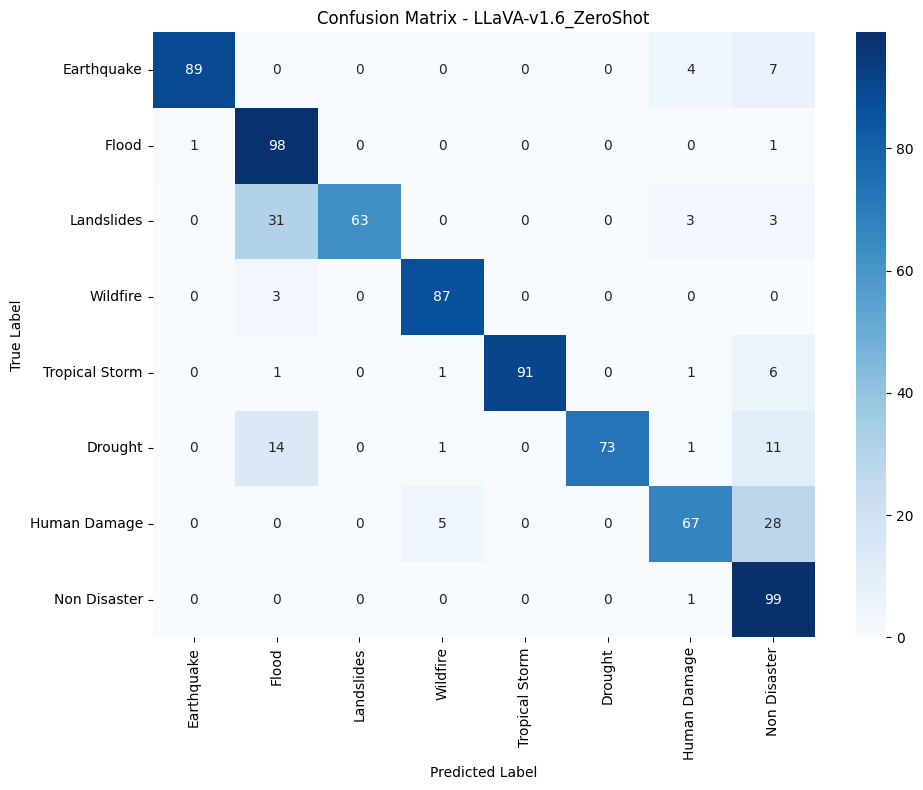


✅ Results saved in ./results/


In [ ]:
from tqdm import tqdm
from PIL import Image

# ====================== PROMPT ======================
PROMPT = "এই ছবিটি এবং টেক্সটটি দেখে বলুন এটি কোন ধরণের দুর্যোগ।"

# ====================== ZERO-SHOT FUNCTION ======================
def llava_zero_shot(df):
    preds = []
    print("Running LLaVA-v1.6 Zero-Shot...")

    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            # Load image
            image = Image.open(row["image_path"]).convert("RGB")

            # Prepare conversation
            conversation = [
                {"role": "user", "content": [
                    {"type": "text", "text": f"{PROMPT}\nছবির টেক্সট: {row['caption']}"},
                    {"type": "image", "image": image}
                ]}
            ]

            prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

            # Process inputs
            inputs = processor(
                images=image,
                text=prompt,
                return_tensors="pt"
            ).to(model.device)

            # Generate
            output = model.generate(
                **inputs,
                max_new_tokens=128,
                do_sample=False,
                temperature=0.0
            )

            response = processor.decode(output[0], skip_special_tokens=True)
            parsed = parse_prediction(response)
            preds.append(parsed)

        except Exception as e:
            print(f"Error on one image: {e}")
            preds.append("Non-Disaster")

    return preds


# ====================== RUN ======================
llava_predictions = llava_zero_shot(test_df)

# Evaluate
llava_acc, llava_prec, llava_rec, llava_f1 = evaluate_model(
    predictions=llava_predictions,
    true_labels=test_df["true_label"].tolist(),
    model_name="LLaVA-v1.6_ZeroShot"
)


=== LLaVA-v1.6_ZeroShot Zero-Shot Evaluation ===
Total samples : 790

Predicted class distribution:
Non Disaster      155
Flood             147
Wildfire           94
Tropical Storm     91
Earthquake         90
Human Damage       77
Drought            73
Landslides         63
Name: count, dtype: int64

Accuracy           : 84.43%
Macro Precision    : 88.62%
Macro Recall       : 84.58%
Macro F1-score     : 84.74%

Classification Report:
                precision    recall  f1-score   support

    Earthquake     0.9889    0.8900    0.9368       100
         Flood     0.6667    0.9800    0.7935       100
    Landslides     1.0000    0.6300    0.7730       100
      Wildfire     0.9255    0.9667    0.9457        90
Tropical Storm     1.0000    0.9100    0.9529       100
       Drought     1.0000    0.7300    0.8439       100
  Human Damage     0.8701    0.6700    0.7571       100
  Non Disaster     0.6387    0.9900    0.7765       100

      accuracy                         0.8443       79

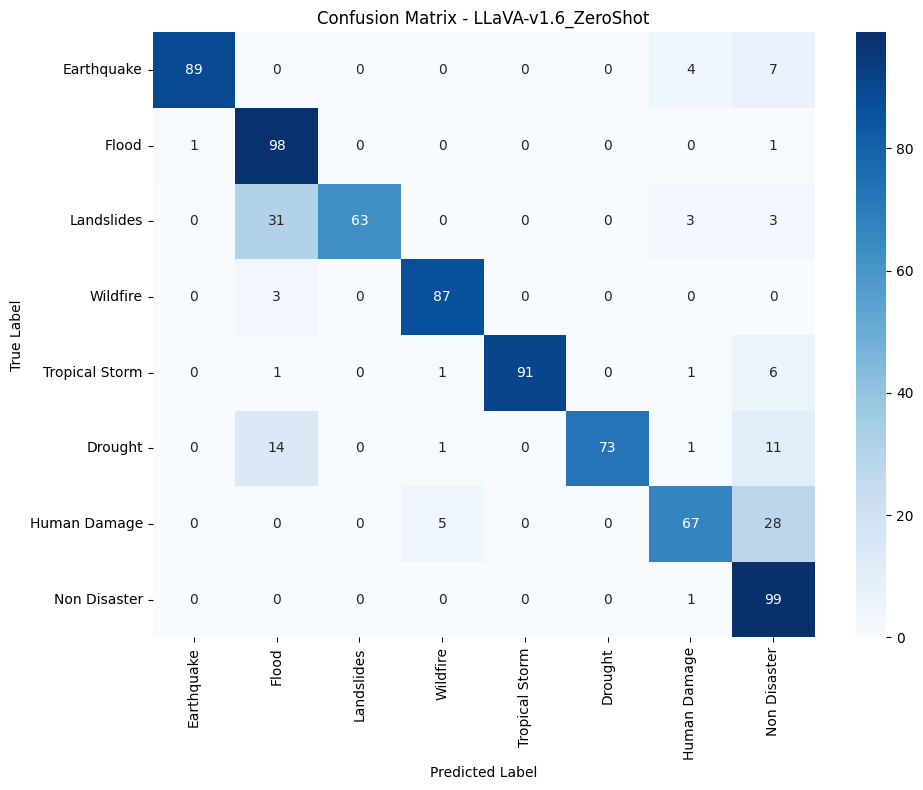


✅ Results saved in ./results/


In [ ]:
# Evaluate
llava_acc, llava_prec, llava_rec, llava_f1 = evaluate_model(
    predictions=llava_predictions,
    true_labels=test_df["true_label"].tolist(),
    model_name="LLaVA-v1.6_ZeroShot"
)

### Gemma-3-4B

Major Challenge: The API token

In [ ]:
from huggingface_hub import login

login("HUGGINGFACE TOKEN")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.6 MB/s eta 0:00:00
Loading Gemma-3-4B-IT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

✅ Gemma 3 loaded successfully!
Running Gemma-3 Zero-Shot Evaluation...


100%|██████████| 790/790 [2:14:37<00:00, 10.22s/it]



=== Gemma-3-4B_ZeroShot Zero-Shot Evaluation ===
Total samples : 790

Predicted class distribution:
Flood             184
Earthquake        109
Tropical Storm     97
Wildfire           92
Non Disaster       87
Human Damage       77
Landslides         75
Drought            69
Name: count, dtype: int64

Accuracy           : 81.01%
Macro Precision    : 85.39%
Macro Recall       : 81.04%
Macro F1-score     : 81.62%

Classification Report:
                precision    recall  f1-score   support

    Earthquake     0.8991    0.9800    0.9378       100
         Flood     0.5163    0.9500    0.6690       100
    Landslides     0.9733    0.7300    0.8343       100
      Wildfire     0.8152    0.8333    0.8242        90
Tropical Storm     0.9485    0.9200    0.9340       100
       Drought     0.9420    0.6500    0.7692       100
  Human Damage     0.9091    0.7000    0.7910       100
  Non Disaster     0.8276    0.7200    0.7701       100

      accuracy                         0.8101       79

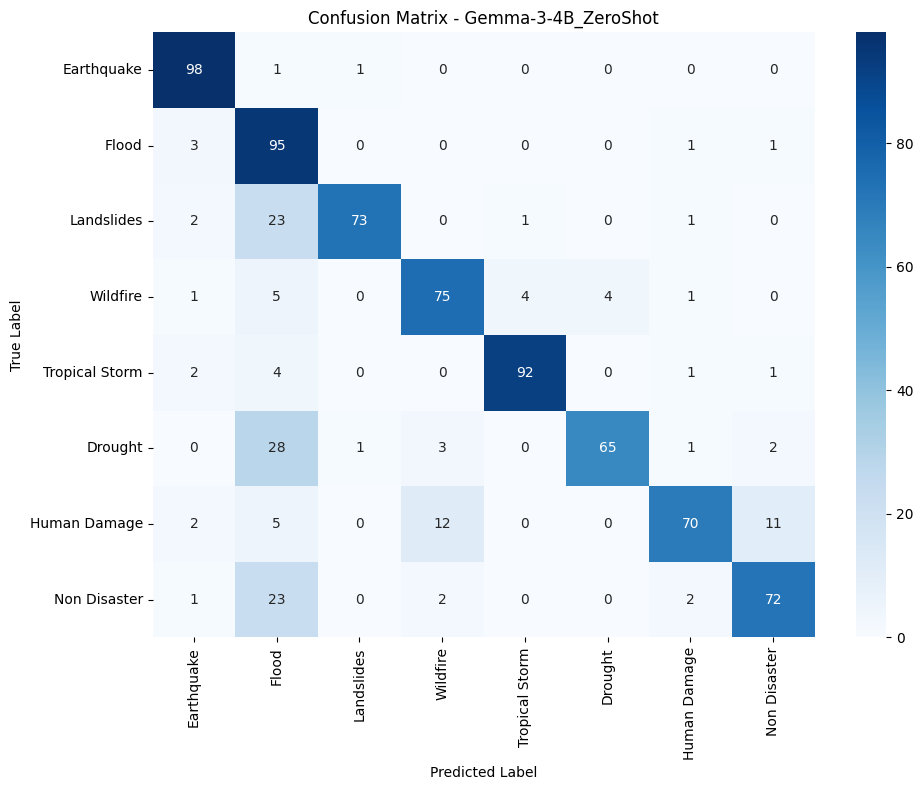


✅ Results saved in ./results/


In [ ]:
# ====================== 1. INSTALL ======================
!pip install -q transformers accelerate bitsandbytes

import torch
from transformers import AutoProcessor, Gemma3ForConditionalGeneration, BitsAndBytesConfig
from tqdm import tqdm
from PIL import Image
import gc

# Clear memory
torch.cuda.empty_cache()
gc.collect()

# ====================== 2. LOAD GEMMA 3 ======================
print("Loading Gemma-3-4B-IT...")

model_id = "google/gemma-3-4b-it"

# 4-bit Config
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=quantization_config,
    trust_remote_code=True
)

print("✅ Gemma 3 loaded successfully!")

# ====================== 3. PROMPT ======================
PROMPT = "এই ছবিটি এবং টেক্সটটি দেখে বলুন এটি কোন ধরণের দুর্যোগ।"

# ====================== 4. ZERO-SHOT FUNCTION ======================
def gemma3_zero_shot(df):
    preds = []
    print("Running Gemma-3 Zero-Shot Evaluation...")

    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            image = Image.open(row["image_path"]).convert("RGB")

            # Prepare messages
            messages = [{
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": f"{PROMPT}\nছবির টেক্সট: {row['caption']}"}
                ]
            }]

            # Process inputs
            inputs = processor.apply_chat_template(
                messages,
                add_generation_prompt=True,
                tokenize=True,
                return_tensors="pt"
            ).to(model.device)

            # Generate
            generated_ids = model.generate(
                inputs,
                max_new_tokens=80,
                do_sample=False,
                temperature=0.0
            )

            response = processor.decode(generated_ids[0], skip_special_tokens=True)
            parsed = parse_prediction(response)
            preds.append(parsed)

        except Exception as e:
            print(f"Error on one image: {e}")
            preds.append("Non-Disaster")

    return preds


# ====================== 5. RUN ======================
gemma_predictions = gemma3_zero_shot(test_df)

# Evaluate
gemma_acc, gemma_prec, gemma_rec, gemma_f1 = evaluate_model(
    predictions=gemma_predictions,
    true_labels=test_df["true_label"].tolist(),
    model_name="Gemma-3-4B_ZeroShot"
)